# 05 · Business Questions — 31 Answers an Anime Streaming Platform Would Pay For

**Business objective.** Modules 2–5 built the machinery (clean star schema, EDA, SQL,
governed KPIs). This notebook does the actual job of an analyst: it takes the questions
stakeholders ask — *which genres deserve licensing budget? why do subscribers leave? does
buffering really cost us money?* — and answers each one in the house format:

> **Analysis** (the numbers) → **Insight** (what they mean) → **Recommendation** (what to do)

**31 questions in six themes**

| Theme | Questions | Stakeholder |
|---|---|---|
| A · Content strategy & licensing | Q1–Q6 | Content acquisition |
| B · Acquisition & conversion | Q7–Q11 | Growth / Marketing |
| C · Retention & churn | Q12–Q17 | Lifecycle / CRM |
| D · Viewing behaviour | Q18–Q22 | Product |
| E · Quality of experience | Q23–Q27 | Engineering / Ops |
| F · Revenue & the executive view | Q28–Q31 | Leadership |

Three of these answers are deliberately *negative* findings (Q6, Q7, Q11a) and one is a
confound warning (Q24) — knowing when the data says "no effect" is as valuable as a
positive result, and interviewers probe for exactly that judgment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ---- palette (validated categorical order + chrome inks, same as Modules 3-5) ----
CAT = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
BLUE, GREEN, AMBER = CAT[0], CAT[1], CAT[3]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "Segoe UI", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})


def style(ax, ygrid_only=True, pct=False):
    ax.grid(axis="y" if ygrid_only else "x")
    if pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))


def ranked_hbar(s, title, xlabel, fmt="{:,.0f}", figsize=(9, 4.4)):
    """Ranking chart: horizontal bars, one hue, largest on top, labelled ends."""
    fig, ax = plt.subplots(figsize=figsize)
    s = s.sort_values()
    ax.barh(s.index.astype(str), s.values, color=BLUE, height=0.62)
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in s.values],
                 padding=4, color=INK2, fontsize=9)
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.margins(x=0.10)
    style(ax, ygrid_only=False)
    plt.tight_layout()
    plt.show()


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
P = PROJECT_ROOT / "data" / "processed"

# the wide clean table (events + user + content attributes) does most of the work here
ev = pd.read_csv(P / "anime_streaming_clean.csv",
                 parse_dates=["Watch_Date", "Subscription_Start_Date", "Subscription_End_Date"])
ev["Hours"] = ev["Watch_Time_Minutes"] / 60
ev["Day"] = ev["Watch_Date"].dt.normalize()

users = pd.read_csv(P / "dim_user.csv")
subs = pd.read_csv(P / "fact_subscriptions.csv",
                   parse_dates=["Subscription_Start_Date", "Subscription_End_Date"])
content = pd.read_csv(P / "dim_content.csv")

usub = users.merge(subs.drop(columns=["Subscription_Plan", "Subscription_Status"]), on="User_ID")
usub["Churned"] = usub["Retention_Status"].isin(["Early Churn (<=3m)", "Churned"])

# per-user event aggregates, reused by several questions
user_beh = ev.groupby("User_ID").agg(Avg_Buffering=("Buffering_Time", "mean"),
                                     Total_Hours=("Hours", "sum"),
                                     Avg_Completion=("Completion_Percentage", "mean"))

N_QUESTIONS = 0  # incremented by each question cell; checked in validation

print(f"{len(ev):,} events | {len(usub):,} users | {len(content):,} titles")

41,046 events | 7,993 users | 64 titles


## Theme A — Content Strategy & Licensing

The content budget is the biggest line item a streaming platform has. These six questions tell the acquisition team **what to license, what to renew, and what to stop believing** about the catalogue.

### Q1. Where do watch hours actually go — which genres carry the platform?

*Licensing negotiations start from consumption share: which shelves keep the lights on.*

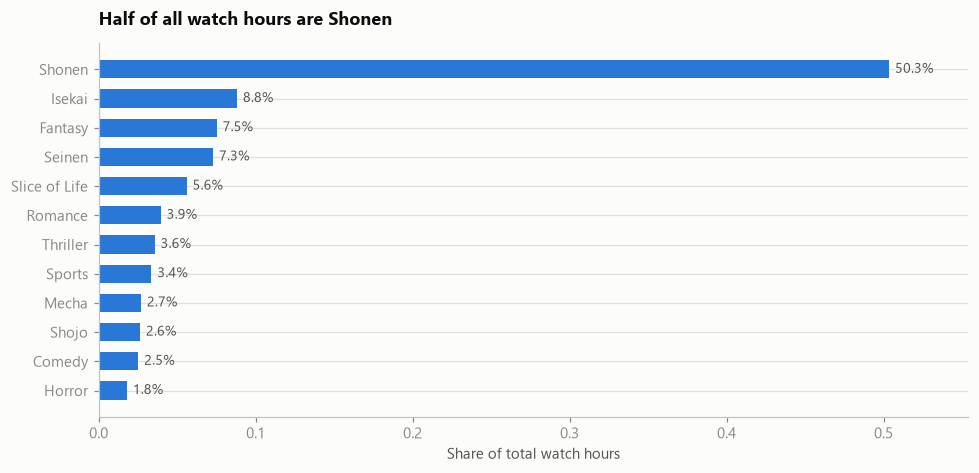

In [2]:
N_QUESTIONS += 1
genre_hours = ev.groupby("Genre")["Hours"].sum().sort_values(ascending=False)
genre_share = genre_hours / genre_hours.sum()
ranked_hbar(genre_share, "Half of all watch hours are Shonen", "Share of total watch hours",
            fmt="{:.1%}")

**Insight.** **Shonen alone carries 50.3% of all watch hours** — more than the next six genres combined. Isekai (8.8%), Fantasy (7.5%) and Seinen (7.3%) form a distant second tier; everything else is single digits. The platform's consumption is extremely concentrated.

**Recommendation.** Treat the Shonen pipeline as load-bearing: protect those renewals first in licensing negotiations. Fund the second tier (Isekai, Fantasy, Seinen) as diversification bets — 50% dependence on one genre is a real business risk if a rival outbids us there.

### Q2. Which genres keep viewers watching once they press play?

*Hours measure what people *start*; completion and rating measure what the catalogue *delivers*.*

In [3]:
N_QUESTIONS += 1
(ev.groupby("Genre")
   .agg(Watch_Hours=("Hours", "sum"), Avg_Completion=("Completion_Percentage", "mean"),
        Avg_Rating=("User_Rating", "mean"))
   .sort_values("Avg_Rating", ascending=False).round(2))

,Watch_Hours,Avg_Completion,Avg_Rating
Genre,,,
Fantasy,727.07,62.17,8.04
Thriller,344.45,62.09,7.95
Shonen,4874.14,61.87,7.93
Seinen,705.11,61.82,7.73
Comedy,243.40,59.80,7.69
Sports,324.48,62.19,7.62
Mecha,260.05,61.13,7.62
Romance,381.82,60.77,7.60
Slice of Life,541.56,60.70,7.58


**Insight.** Completion is remarkably uniform (59.8–62.2% — no genre is a completion outlier), but ratings spread: Fantasy (8.04), Thriller (7.95) and Shonen (7.93) lead, while Horror (7.18) and **Isekai (7.23) sit at the bottom. Isekai is the anomaly: #2 in hours, second-worst in rating** — high consumption, low satisfaction.

**Recommendation.** Audit the Isekai shelf: viewers clearly want the genre but current titles disappoint, so upgrading it has the largest satisfaction upside per hour watched. Horror is the opposite case — low hours *and* low ratings — a candidate for letting licenses lapse.

### Q3. Which studios deliver the highest-rated content?

*Studio relationships (output deals, first-look agreements) are multi-year bets on quality.*

In [4]:
N_QUESTIONS += 1
studio = (ev.groupby("Studio")
            .agg(Events=("Event_ID", "count"), Watch_Hours=("Hours", "sum"),
                 Avg_Rating=("User_Rating", "mean"))
            .query("Events >= 500").sort_values("Avg_Rating", ascending=False).round(2))
studio

,Events,Watch_Hours,Avg_Rating
Studio,,,
Toei Animation,5100,1216.46,8.11
MAPPA,6921,1651.23,8.03
Madhouse,4526,1075.24,7.99
Ufotable,2241,531.90,7.94
Doga Kobo,525,125.31,7.93
Studio Trigger,536,125.03,7.88
White Fox,946,223.52,7.79
Wit Studio,1271,297.62,7.77
Sunrise,825,193.72,7.76


**Insight.** Among studios with meaningful volume (≥500 events), **Toei Animation (8.11), MAPPA (8.03) and Madhouse (7.99) top the ratings; MAPPA pairs that with the largest event volume of any studio (6.9k)** — quality at scale. At the other end, 8bit, Studio Deen and CloverWorks trail around 7.4.

**Recommendation.** Prioritize renewal and first-look deals with MAPPA and Toei — they are the proven quality-at-volume suppliers. Price trailing-studio acquisitions as catalogue fill, not headliners.

### Q4. Do the most-watched titles overlap with the best-rated ones?

*If volume hits and quality hits are different lists, they are different licensing jobs.*

In [5]:
N_QUESTIONS += 1
title_stats = ev.groupby("Anime_Title").agg(Watch_Hours=("Hours", "sum"),
                                            Avg_Rating=("User_Rating", "mean"),
                                            Events=("Event_ID", "count"))
top_hours = title_stats.nlargest(10, "Watch_Hours")
top_rating = title_stats.query("Events >= 200").nlargest(10, "Avg_Rating")
overlap = set(top_hours.index) & set(top_rating.index)
print("Top-10 by HOURS :", ", ".join(top_hours.index))
print("Top-10 by RATING:", ", ".join(top_rating.index))
print(f"\nOverlap ({len(overlap)}):", ", ".join(sorted(overlap)))

Top-10 by HOURS : One Piece, Attack on Titan, Demon Slayer: Kimetsu no Yaiba, Jujutsu Kaisen, My Hero Academia, Naruto Shippuden, Solo Leveling, Chainsaw Man, Frieren: Beyond Journey's End, Spy x Family
Top-10 by RATING: Fullmetal Alchemist: Brotherhood, Frieren: Beyond Journey's End, Attack on Titan, Steins;Gate, Hunter x Hunter, Monster, Bleach: Thousand-Year Blood War, Death Note, Gintama, One Piece

Overlap (3): Attack on Titan, Frieren: Beyond Journey's End, One Piece


**Insight.** Only **3 of 10 titles appear on both lists** (One Piece, Attack on Titan, Frieren). Blockbusters like Naruto, Jujutsu Kaisen and Demon Slayer drive volume without topping ratings, while a distinct "critics' shelf" (Steins;Gate, Monster, Fullmetal Alchemist: Brotherhood, Hunter x Hunter) earns love without volume.

**Recommendation.** Run two content plays: blockbusters are *acquisition* assets (market them outward); the high-rating, under-watched shelf is a *satisfaction* asset that is already paid for — surface it in onboarding rows and recommendations to deepen engagement at zero licensing cost.

### Q5. Does catalogue depth (episode count) pay off in engagement?

*Long-running franchises cost more to license — do they earn it back in hours?*

In [6]:
N_QUESTIONS += 1
depth = title_stats.join(content.set_index("Anime_Title")["Episodes_Available"])
depth["Depth"] = pd.cut(depth["Episodes_Available"], [0, 12, 24, 10_000],
                        labels=["<=12 eps", "13-24 eps", "25+ eps"])
corr = depth["Episodes_Available"].corr(depth["Watch_Hours"])
print(f"Correlation, episodes available vs hours per title: {corr:.2f}")
depth.groupby("Depth", observed=True).agg(Titles=("Watch_Hours", "size"),
                                          Hours_per_Title=("Watch_Hours", "mean")).round(1)

Correlation, episodes available vs hours per title: 0.70


,Titles,Hours_per_Title
Depth,,
<=12 eps,11,87.4
13-24 eps,12,101.9
25+ eps,41,182.9


**Insight.** Depth pays: **25+ episode titles average 183 watch hours each, vs 87 for short (≤12-episode) seasons** — and the title-level correlation between episode count and hours is 0.70. Long-runners amortize their licensing cost over far more viewing and provide the raw material for binges (Q20).

**Recommendation.** Weight the licensing portfolio toward multi-season franchises; a short season should clear a higher quality bar (Q4's critics' shelf) to justify its slot.

### Q6. Do churned users have different genre tastes than retained users? (negative finding)

*"We lose people because we lack genre X" is a common executive theory. Test it.*

In [7]:
N_QUESTIONS += 1
ret_flag = np.where(ev["Retention_Status"].isin(["Active", "Loyal (12m+ active)"]),
                    "Retained", "Churned")
mix = ev.groupby([ret_flag, "Genre"])["Event_ID"].count().unstack(0)
mix = (mix / mix.sum()).round(3)
mix["Difference (pp)"] = ((mix["Retained"] - mix["Churned"]) * 100).round(1)
mix.sort_values("Difference (pp)", ascending=False)

,Churned,Retained,Difference (pp)
Genre,,,
Shojo,0.020,0.030,1.0
Isekai,0.084,0.093,0.9
Mecha,0.024,0.029,0.5
Fantasy,0.071,0.076,0.5
Thriller,0.036,0.035,-0.1
Horror,0.019,0.018,-0.1
Comedy,0.027,0.025,-0.2
Sports,0.035,0.032,-0.3
Shonen,0.504,0.499,-0.5


**Insight.** **No.** The genre mix of churned vs retained users' viewing differs by at most ±1.1 percentage points — churners watched essentially the same shelves as loyalists. Retention is not about *what* people watch here.

**Recommendation.** Retire the "churn genre" theory in content meetings. Churn-reduction budget belongs in experience factors — buffering (Q23–25), the first-month experience (Q16) and habit-building (Q11, Q20) — not catalogue reshuffles.

## Theme B — Acquisition & Conversion

Growth spend needs to know which channels bring *good* users, who among the free base is ready to pay, and what the paid experience is actually worth.

### Q7. Which acquisition channels deliver the best users — not just the most?

*Channel reports usually rank volume. Quality (paid mix, retention, LTV) is what matters.*

In [8]:
N_QUESTIONS += 1
channel = (usub.groupby("Referral_Source")
               .agg(Users=("User_ID", "count"), Paid_Mix=("Monthly_Fee", lambda s: (s > 0).mean()),
                    Churn_Rate=("Churned", "mean"), Avg_Engagement=("Engagement_Score", "mean"),
                    Avg_Lifetime_Revenue=("Revenue", "mean"))
               .sort_values("Avg_Lifetime_Revenue", ascending=False).round(3))
channel

,Users,Paid_Mix,Churn_Rate,Avg_Engagement,Avg_Lifetime_Revenue
Referral_Source,,,,,
Advertisement,939,0.614,0.548,49.817,48.574
YouTube,1131,0.611,0.584,49.533,48.123
Social Media,2205,0.609,0.561,50.233,47.413
Friend Referral,1741,0.596,0.548,49.870,47.406
Google Search,1477,0.582,0.559,50.099,44.732
App Store,500,0.580,0.554,50.637,43.013


**Insight.** The volume leader (Social Media, 2,205 users) is mid-pack on every quality measure. Advertisement tops lifetime revenue ($48.6/user) and paid mix (61.4%); App Store trails ($43.0). But the honest headline is **how narrow the spread is — ~13% top-to-bottom on LTV, ~3pp on churn. No channel is broken and none is a goldmine.**

**Recommendation.** With user quality this uniform, channel allocation should be decided by **acquisition cost**, which this dataset doesn't capture — flag CAC per channel as the top data requirement for marketing analytics (also noted for the final report).

### Q8. How many Free users already behave like paying customers?

*The cheapest conversion campaign is the one aimed at people who already act converted.*

In [9]:
N_QUESTIONS += 1
free_u = usub[usub["Subscription_Plan"] == "Free"]
paid_u = usub[usub["Monthly_Fee"] > 0]
paid_median = paid_u["Engagement_Score"].median()
lookalikes = free_u[free_u["Engagement_Score"] >= paid_median]
print(f"Median engagement of PAYING users: {paid_median:.1f}")
print(f"Free users at or above it: {len(lookalikes):,} ({len(lookalikes) / len(free_u):.1%} of the free base)")
print(f"Mean engagement — free: {free_u['Engagement_Score'].mean():.1f}, paid: {paid_u['Engagement_Score'].mean():.1f}")

Median engagement of PAYING users: 56.7
Free users at or above it: 442 (13.8% of the free base)
Mean engagement — free: 39.5, paid: 57.0


**Insight.** **442 free users (13.8% of the free base) are more engaged than the *median paying customer*** (engagement ≥ 56.7). They already consume like payers — they just haven't been asked properly.

**Recommendation.** This list *is* the conversion campaign: a targeted upgrade offer (first-month discount, ad-free/HD messaging per Q9) to these 442 users. Even a 30% take-up at Basic ($4.99) adds ~$660/month of MRR from one email — and the play repeats every quarter as the list refills.

### Q9. What does paying actually change in behaviour — the conversion pitch?

*To sell the upgrade, quantify the gap between the free and paid experience.*

In [10]:
N_QUESTIONS += 1
(ev.groupby("Subscription_Plan")
   .agg(Viewers=("User_ID", "nunique"), Hours_per_User=("Hours", "sum"),
        Avg_Completion=("Completion_Percentage", "mean"), Avg_Rating=("User_Rating", "mean"))
   .assign(Hours_per_User=lambda d: d["Hours_per_User"] / d["Viewers"])
   .loc[["Free", "Basic", "Premium", "Family"]].round(2))

,Viewers,Hours_per_User,Avg_Completion,Avg_Rating
Subscription_Plan,,,,
Free,3195,0.45,53.99,7.22
Basic,2018,0.95,59.85,7.62
Premium,1992,2.04,63.69,7.93
Family,788,2.86,64.91,7.99


**Insight.** Paying users watch **2–6× more** (Family 2.86 and Premium 2.04 hours/user vs Free 0.45), finish more (completion 64–65% vs 54%) and rate content higher (7.9–8.0 vs 7.2). Causality runs both ways — engaged people are the ones who buy — but the experience gap (ad-free, HD) is real and measurable.

**Recommendation.** Market the *experience delta*, not the catalogue (Free sees the same shows): "watch more, finish more, no ads." Use Q8's lookalike list as the audience and this table as the creative brief.

### Q10. Where are the geographic conversion gaps?

*If two markets have equally keen users but different paid mix, the gap is fixable (pricing, payments).*

In [11]:
N_QUESTIONS += 1
geo = (usub.groupby("Country")
           .agg(Users=("User_ID", "count"), Paid_Mix=("Monthly_Fee", lambda s: (s > 0).mean()),
                Avg_Engagement=("Engagement_Score", "mean"))
           .query("Users >= 200").sort_values("Paid_Mix").round(3))
geo

,Users,Paid_Mix,Avg_Engagement
Country,,,
Canada,421,0.563,48.242
Indonesia,388,0.572,47.479
Philippines,457,0.578,51.277
Japan,1035,0.588,49.794
USA,1718,0.593,49.506
UK,474,0.597,50.961
South Korea,236,0.606,50.281
Mexico,518,0.612,50.765
Brazil,709,0.619,49.790


**Insight.** Paid mix spans **56.3% (Canada) to 64.4% (Germany)** — and engagement is flat across countries (~48–52), so the gap is not about enthusiasm. Notably, the two biggest bases — **USA (1,718 users, 59.3%) and Japan (1,035, 58.8%) — convert below the top quartile.**

**Recommendation.** Run pricing/payment-method experiments in the large under-converting markets first (USA, Japan, Canada): closing them to Germany's 64% is worth roughly 80 extra payers in the USA alone, versus single digits in small markets.

### Q11. Does *how* users discover content change outcomes — and what actually does?

*Product wants to know which discovery surfaces to invest in. The data has a twist.*

In [12]:
N_QUESTIONS += 1
print("By discovery surface (flat -> negative finding):")
display(ev.groupby("Search_Source")
          .agg(Events=("Event_ID", "count"), Avg_Completion=("Completion_Percentage", "mean"),
               Avg_Rating=("User_Rating", "mean")).round(2))

has_watchlist = ev.groupby("User_ID")["Watchlist"].max().rename("Ever_Watchlisted")
wl = users.merge(has_watchlist, on="User_ID")
wl["Churned"] = wl["Retention_Status"].isin(["Early Churn (<=3m)", "Churned"])
print("\nBy whether the user ever ADDS to watchlist (the real signal):")
wl.groupby("Ever_Watchlisted").agg(Users=("User_ID", "count"), Churn_Rate=("Churned", "mean"),
                                   Avg_Engagement=("Engagement_Score", "mean")).round(3)

By discovery surface (flat -> negative finding):


,Events,Avg_Completion,Avg_Rating
Search_Source,,,
Browse,12332,61.62,7.80
Recommendation,8996,61.32,7.73
Search Bar,10174,61.57,7.74
Trending,4115,61.35,7.80
Watchlist,5429,61.68,7.83



By whether the user ever ADDS to watchlist (the real signal):


,Users,Churn_Rate,Avg_Engagement
Ever_Watchlisted,,,
0,4640,0.664,43.432
1,3353,0.413,59.105


**Insight.** The discovery surface itself is a **negative finding** — completion is 61.3–61.7% whether a session came from Search, Browse, Trending or Recommendations. But *saving* behaviour is enormously predictive: **users who ever add to a watchlist churn at 41.3% vs 66.4% for those who never do** (engagement 59.1 vs 43.4).

**Recommendation.** Stop optimizing which shelf gets clicks and start optimizing **watchlist adds as the activation metric**: prompt a save during onboarding, badge it in the UI, and track "% of new users with ≥1 watchlist add in week 1" as a leading retention indicator.

## Theme C — Retention & Churn

The KPI layer showed a ~7%/month leak with 59% of churn in the first 3 months. These six questions find out **who leaves, why, and what would have kept them**.

### Q12. Why do subscribers say they leave?

*Exit reasons are the cheapest churn research we have — start with the stated story.*

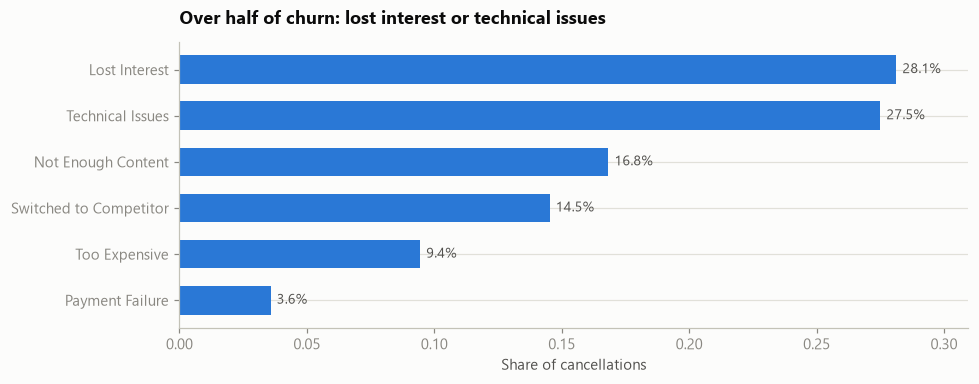

In [13]:
N_QUESTIONS += 1
reasons = subs["Cancellation_Reason"].value_counts(normalize=True)
ranked_hbar(reasons, "Over half of churn: lost interest or technical issues",
            "Share of cancellations", fmt="{:.1%}", figsize=(9, 3.6))

**Insight.** **Lost Interest (28.1%) and Technical Issues (27.5%) together explain over half of all churn.** Price ("Too Expensive") is cited by just 9.4%, and involuntary churn (payment failure) by 3.6%.

**Recommendation.** Churn here is an engagement + quality problem, not a pricing problem — discount-led win-back campaigns target the wrong 9%. The budget belongs in QoS (Theme E) and first-month engagement (Q16).

### Q13. Do exit reasons differ by plan?

*If Basic churners leave over price and Premium over content, retention offers should differ too.*

In [14]:
N_QUESTIONS += 1
by_plan = (subs[subs["Subscription_Status"] == "Cancelled"]
           .pivot_table(index="Cancellation_Reason", columns="Subscription_Plan",
                        values="User_ID", aggfunc="count"))
(by_plan / by_plan.sum()).round(3)[["Free", "Basic", "Premium", "Family"]]

Subscription_Plan,Free,Basic,Premium,Family
Cancellation_Reason,,,,
Lost Interest,0.343,0.226,0.233,0.214
Not Enough Content,0.189,0.147,0.148,0.169
Payment Failure,NaN,0.074,0.056,0.075
Switched to Competitor,0.162,0.133,0.122,0.146
Technical Issues,0.306,0.246,0.259,0.220
Too Expensive,NaN,0.175,0.182,0.176


**Insight.** Two useful facts. First, **"Too Expensive" is a paid-tier constant (17.5–18.2% on every paid plan)** — Basic churners are no more price-sensitive than Premium ones, which argues against the intuition that the cheap tier attracts bargain hunters. Second, Free accounts over-index on Lost Interest (34.3%) and Technical Issues (30.6%) — the ad-supported experience wears people out (they can't cite price, mechanically).

**Recommendation.** One retention playbook per tier is enough on price (a single downgrade-path offer), but the Free tier needs its own fix: its exit profile says the *experience* — ads plus buffering — is what expires, which threatens the Q8 conversion pipeline upstream.

### Q14. Do stated exit reasons match actual behaviour?

*Survey answers are cheap talk unless the logs agree. Cross-examine each reason cohort.*

In [15]:
N_QUESTIONS += 1
churned_u = usub[usub["Subscription_Status"] == "Cancelled"].merge(user_beh, on="User_ID")
(churned_u.groupby("Cancellation_Reason")
          .agg(Users=("User_ID", "count"), Avg_Buffering=("Avg_Buffering", "mean"),
               Total_Hours=("Total_Hours", "mean"), Engagement=("Engagement_Score", "mean"),
               CSAT=("Customer_Satisfaction", "mean"), Tenure_Months=("Membership_Tenure", "mean"))
          .sort_values("Users", ascending=False).round(2))

,Users,Avg_Buffering,Total_Hours,Engagement,CSAT,Tenure_Months
Cancellation_Reason,,,,,,
Lost Interest,1257,8.81,0.54,44.58,6.95,4.97
Technical Issues,1229,9.55,0.71,48.82,6.89,4.88
Not Enough Content,752,8.27,0.61,48.06,7.02,4.76
Switched to Competitor,649,8.66,0.70,47.49,7.02,5.08
Too Expensive,422,7.96,0.91,51.58,6.99,5.46
Payment Failure,160,9.21,1.18,56.90,7.22,5.92


**Insight.** The stories check out, which is rare and valuable: **"Technical Issues" churners suffered the worst buffering (9.6 min/event); "Lost Interest" churners had the lowest engagement (44.6) and hours; "Too Expensive" churners were relatively *engaged* (51.6) with below-average buffering — they liked the product, not the price; and "Payment Failure" churners were the most engaged of all (56.9)** — involuntary losses of good customers.

**Recommendation.** Segment win-back by reason: card-retry + grace-period flows for payment failures (the cheapest saves — they didn't want to leave), a downgrade path for price churners, and a "we fixed it" campaign for technical churners *only after* QoS metrics actually improve (Q25).

### Q15. How does churn risk fall with tenure?

*If risk concentrates early, retention budget should too. Quantify the hazard curve.*

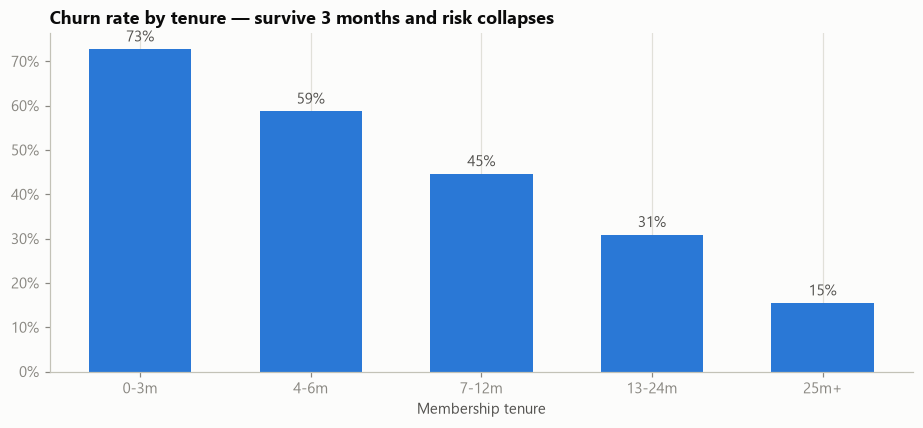

In [16]:
N_QUESTIONS += 1
tenure = usub.assign(Bucket=pd.cut(usub["Membership_Tenure"], [0, 3, 6, 12, 24, 999],
                                   labels=["0-3m", "4-6m", "7-12m", "13-24m", "25m+"]))
hz = tenure.groupby("Bucket", observed=True).agg(Users=("User_ID", "count"),
                                                 Churn_Rate=("Churned", "mean"))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(hz.index.astype(str), hz["Churn_Rate"], color=BLUE, width=0.6)
ax.bar_label(ax.containers[0], labels=[f"{v:.0%}" for v in hz["Churn_Rate"]],
             padding=3, color=INK2, fontsize=10)
ax.set_title("Churn rate by tenure — survive 3 months and risk collapses")
ax.set_xlabel("Membership tenure")
style(ax, pct=True)
plt.tight_layout()
plt.show()

**Insight.** Churn falls monotonically from **73% in months 0–3 to 15% past two years** — roughly halving with each tenure band. Every additional month a user survives makes the next month safer (the generator's churn-hazard design, recovered cleanly from the data).

**Recommendation.** Weight retention spend by hazard: a month-2 save is worth ~5× a month-25 save. Concretely — onboarding flows, first-week content matching and early QoS priority should outrank anniversary perks and long-tenure loyalty gestures in the budget.

### Q16. What does an early churner's first month actually look like?

*"They churn because they never showed up" is the default assumption. Check it.*

In [17]:
N_QUESTIONS += 1
first30 = ev[ev["Watch_Date"] <= ev["Subscription_Start_Date"] + pd.Timedelta(days=30)]
f30 = first30.groupby("User_ID").agg(Events_30d=("Event_ID", "count"),
                                     Hours_30d=("Hours", "sum"),
                                     Completion_30d=("Completion_Percentage", "mean"))
cohort = users.merge(f30, on="User_ID", how="left")
cohort[["Events_30d", "Hours_30d"]] = cohort[["Events_30d", "Hours_30d"]].fillna(0)
cohort["Group"] = np.where(cohort["Retention_Status"] == "Early Churn (<=3m)",
                           "Early churner", "Everyone else")
cohort.groupby("Group").agg(Users=("User_ID", "count"),
                            Watched_in_30d=("Events_30d", lambda s: (s > 0).mean()),
                            Avg_Events=("Events_30d", "mean"),
                            Avg_Completion=("Completion_30d", "mean")).round(2)

,Users,Watched_in_30d,Avg_Events,Avg_Completion
Group,,,,
Early churner,2619,0.75,0.81,54.22
Everyone else,5374,0.40,0.64,58.69


**Insight.** The assumption is wrong: **75% of early churners watched something in their first 30 days** (vs 40% of everyone else — many long-tenure users ramped up later). Early churners *tried* the product; what differed was session quality — their first-month completion was **54.2% vs 58.7%**. They showed up, and it didn't land.

**Recommendation.** Onboarding fixes should target the quality of the first sessions, not attendance: a content-match quiz at sign-up, QoS priority for new accounts (Theme E), and a first-session watchlist prompt (Q11). Reminder-email nudges treat a problem these users didn't have.

### Q17. Does satisfaction predict churn?

*CSAT is cheap to collect. Is it worth wiring into a churn-risk model?*

In [18]:
N_QUESTIONS += 1
csat = usub.assign(Band=pd.cut(usub["Customer_Satisfaction"], [0, 5, 7, 10],
                               labels=["3-5 (low)", "6-7 (mid)", "8-10 (high)"]))
csat.groupby("Band", observed=True).agg(Users=("User_ID", "count"),
                                        Churn_Rate=("Churned", "mean")).round(3)

,Users,Churn_Rate
Band,,
3-5 (low),616,0.661
6-7 (mid),4535,0.582
8-10 (high),2842,0.501


**Insight.** Cleanly: churn falls from **66% (CSAT 3–5) through 58% (6–7) to 50% (8–10)** — a 16-point spread. But note the ceiling: even delighted users churn at 50% in this market, so satisfaction is *protective, not sufficient*.

**Recommendation.** Wire CSAT into a churn-risk score and trigger interventions below 6 — but combine it with the behavioural flags that carry independent signal (watchlist adds Q11, binge days Q20) rather than using it alone.

## Theme D — Viewing Behaviour

When, where, and how people watch — the product team's map for scheduling, device investment, and habit-building.

### Q18. When does the platform actually get watched?

*Scheduling, marketing pushes and capacity planning all hang off the demand curve.*

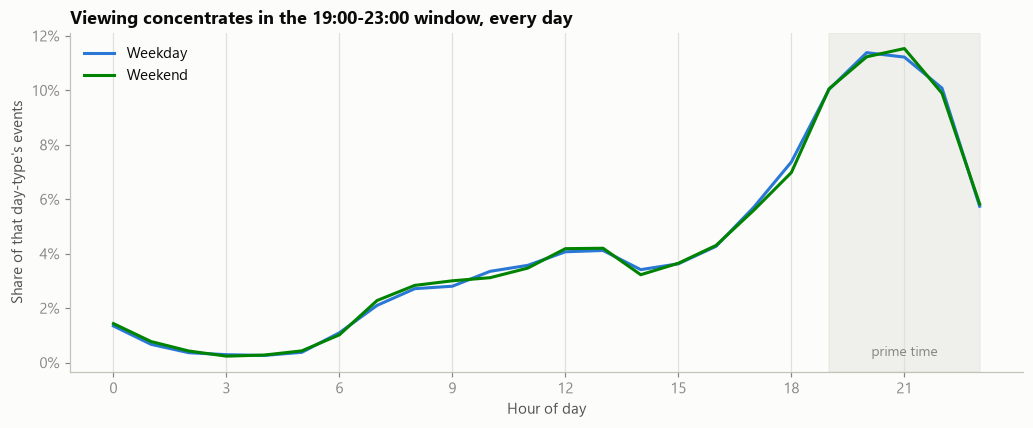

Events per weekday: 25.2 | per weekend day: 57.8  |  prime-time (19-23h) share of all events: 48.5%


In [19]:
N_QUESTIONS += 1
prof = ev.pivot_table(index="Watch_Hour", columns="Weekend_Viewing",
                      values="Event_ID", aggfunc="count")
prof = prof / prof.sum()
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(prof.index, prof[False], color=BLUE, lw=2, label="Weekday")
ax.plot(prof.index, prof[True], color=GREEN, lw=2, label="Weekend")
ax.axvspan(19, 23, color=GRID, alpha=0.45, zorder=0)
ax.text(21, ax.get_ylim()[1] * 0.02, "prime time", ha="center", color=MUTED, fontsize=9)
ax.set_title("Viewing concentrates in the 19:00-23:00 window, every day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of that day-type's events")
ax.set_xticks(range(0, 24, 3))
ax.legend(loc="upper left")
style(ax, pct=True)
plt.tight_layout()
plt.show()

days = ev.groupby("Weekend_Viewing")["Day"].nunique()
evts = ev.groupby("Weekend_Viewing")["Event_ID"].count()
print(f"Events per weekday: {evts[False] / days[False]:.1f} | per weekend day: {evts[True] / days[True]:.1f}"
      f"  |  prime-time (19-23h) share of all events: {ev['Peak_Hour'].mean():.1%}")

**Insight.** Two rhythms, one conclusion: **19:00–23:00 holds 48.5% of all viewing** on both day types, and **a weekend day is ~2.3× busier than a weekday** (57.8 vs 25.2 events/day; weekends take 49.1% of events from 28.6% of days).

**Recommendation.** Drop simulcasts and marketing pushes Friday evening to catch the weekend wave; plan infrastructure capacity (and the QoS fixes of Theme E) against the weekend-evening peak, not the daily average — the peak is where buffering does its damage.

### Q19. Which devices do people watch on — and does the screen change the outcome?

*Device mix decides where engineering effort lands. One number here should alarm the product team.*

In [20]:
N_QUESTIONS += 1
dev = (ev[ev["Device"] != "Unknown"]
       .groupby("Device")
       .agg(Event_Share=("Event_ID", lambda s: len(s) / len(ev)), Avg_Age=("Age", "mean"),
            Avg_Completion=("Completion_Percentage", "mean"), Avg_Buffering=("Buffering_Time", "mean"))
       .sort_values("Event_Share", ascending=False).round(2))
dev

,Event_Share,Avg_Age,Avg_Completion,Avg_Buffering
Device,,,,
Mobile,0.51,27.48,56.37,11.24
Smart TV,0.20,31.36,70.38,6.13
Desktop,0.17,29.99,66.08,5.53
Tablet,0.12,29.61,62.01,8.58


**Insight.** **Mobile is 51% of all viewing and the worst experience on every measure**: completion 56.4% (vs 70.4% on Smart TV), buffering 11.2 min/event (vs 5.5–6.1 on fixed screens), and the youngest audience (avg 27.5). The platform's *majority* experience is its *minimum* experience.

**Recommendation.** Make mobile QoS the top product investment: adaptive bitrate, download-over-WiFi nudges (see Q25 — the culprit is the network, not the phone). A 5-point completion lift on half of all events moves the platform average more than any catalogue purchase would.

### Q20. Are bingers better customers?

*Binge-watching is streaming folklore for engagement. Check it against retention.*

In [21]:
N_QUESTIONS += 1
binge_flag = (ev.groupby(["User_ID", "Day"]).size() >= 3).groupby("User_ID").max()
bingers = users.merge(binge_flag.rename("Has_Binged"), on="User_ID")
bingers["Churned"] = bingers["Retention_Status"].isin(["Early Churn (<=3m)", "Churned"])
display(bingers.groupby("Has_Binged").agg(Users=("User_ID", "count"), Churn_Rate=("Churned", "mean"),
                                          Avg_Engagement=("Engagement_Score", "mean")).round(3))
print("Share of segment that has ever binged:")
bingers.groupby("Viewer_Segment")["Has_Binged"].mean().sort_values(ascending=False).round(3)

,Users,Churn_Rate,Avg_Engagement
Has_Binged,,,
False,6709,0.611,47.237
True,1284,0.287,64.480


Share of segment that has ever binged:


Viewer_Segment
Power Viewer      0.352
Regular Viewer    0.156
Casual Viewer     0.093
Light Viewer      0.042
Name: Has_Binged, dtype: float64

**Insight.** Dramatically: **users with at least one binge day (3+ episodes) churn at 28.7% vs 61.1% for everyone else** — engagement 64 vs 47. Binging concentrates where you'd expect (35.2% of Power Viewers, 4.2% of Light Viewers), and only 16% of users have ever binged at all.

**Recommendation.** Engineer the first binge: autoplay-next-episode defaults, weekend "full season" spotlights on long-runners (Q5), and drop-day notifications. Honest caveat for the roadmap discussion: this is correlational — bingers may simply *be* the engaged — so validate with an autoplay A/B before scaling the spend.

### Q21. How does age shape viewing?

*Product personas need numbers: who is the core audience and how does behaviour shift with age?*

In [22]:
N_QUESTIONS += 1
age = (ev.groupby("Age_Group")
         .agg(Event_Share=("Event_ID", lambda s: len(s) / len(ev)),
              Avg_Completion=("Completion_Percentage", "mean"),
              Mobile_Share=("Device", lambda s: (s == "Mobile").mean()))
         .round(3))
top_g = ev.groupby(["Age_Group", "Genre"]).size().groupby(level=0).idxmax().str[1]
age["Top_Genre"] = top_g
age

,Event_Share,Avg_Completion,Mobile_Share,Top_Genre
Age_Group,,,,
13-17,0.089,59.061,0.557,Shonen
18-24,0.280,61.057,0.583,Shonen
25-34,0.386,61.175,0.514,Shonen
35-44,0.167,62.747,0.421,Shonen
45+,0.078,65.082,0.339,Shonen


**Insight.** The core audience is **18–34 (67% of all viewing)**. Completion *rises* with age — 59.1% for 13–17 up to 65.1% for 45+ — mirroring the mobile share falling with age: younger viewers sample more, finish less, and watch on the worst screen (Q19). And a myth dies: **Shonen is the #1 genre for every age band** — it's not a youth genre, it's *the* platform genre.

**Recommendation.** Differentiate by age at the experience level, not the catalogue level: under-25s need the mobile QoS fix and snackable formats; 35+ viewers are the natural audience for long-runner completion campaigns and are cheap to retain (they already finish what they start).

### Q22. How much does a season launch actually lift the business?

*The KPI layer showed spiky MAU. Size the launch effect so the content calendar can be used as a growth lever.*

In [23]:
N_QUESTIONS += 1
dates_dim = pd.read_csv(P / "dim_date.csv", parse_dates=["Date"])
launch_months = (dates_dim.assign(M=dates_dim["Date"].dt.to_period("M"))
                          .groupby("M")["Is_Season_Launch"].max())
ev["M"] = ev["Watch_Date"].dt.to_period("M")
mm = ev.groupby("M").agg(MAU=("User_ID", "nunique"), Hours=("Hours", "sum"))
mm["Launch"] = launch_months.reindex(mm.index)
recent = mm[mm.index >= pd.Period("2025-01")]
out = recent.groupby("Launch")[["MAU", "Hours"]].mean().round(0)
out.index = out.index.map({True: "Season-launch month", False: "Regular month"})
print("Monthly averages, Jan 2025 - Jun 2026:")
out.assign(MAU_Lift=[f"{out.loc['Season-launch month', 'MAU'] / out.loc['Regular month', 'MAU'] - 1:+.0%}"
                     if i == "Season-launch month" else "" for i in out.index])

Monthly averages, Jan 2025 - Jun 2026:


,MAU,Hours,MAU_Lift
Launch,,,
Regular month,877.0,348.0,
Season-launch month,1178.0,536.0,+34%


**Insight.** Over the last 18 months, a season-launch month averages **1,178 MAU vs 877 in regular months (+34%) and +54% watch hours** (536 vs 348). The content calendar is one of the strongest levers the platform has — and it currently works *against* stickiness, because the audience arrives together and leaves together (KPI layer: DAU/MAU 0.038).

**Recommendation.** Exploit and smooth: coordinate acquisition campaigns and the Q8 conversion pushes with launch months (arrivals are cheapest when the catalogue is loudest), and stagger exclusive drops into off-months to fill the troughs instead of stacking every premiere in the same four weeks.

## Theme E — Quality of Experience

Delivery quality is the platform's own homework: buffering, support load, and the free tier's ad experience. This is where engineering money turns into CSAT.

### Q23. Does buffering really hurt ratings?

*Content teams get blamed for low ratings. Check how much of a rating is actually the stream, not the show.*

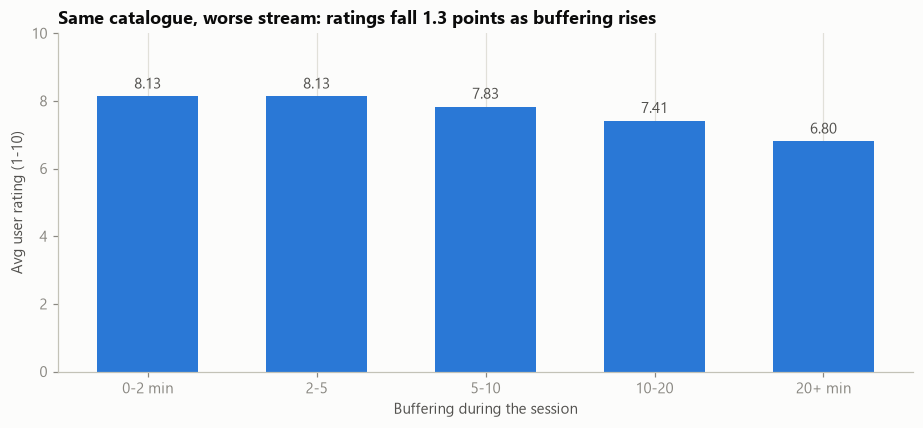

,Events,Avg_Rating,Avg_Completion
Buffering_Time,,,
0-2 min,4022,8.13,65.01
2-5,13303,8.13,64.74
5-10,11119,7.83,62.16
10-20,8810,7.41,57.74
20+ min,3792,6.80,53.45


In [24]:
N_QUESTIONS += 1
bands = pd.cut(ev["Buffering_Time"], [-1, 2, 5, 10, 20, 9999],
               labels=["0-2 min", "2-5", "5-10", "10-20", "20+ min"])
bt = ev.groupby(bands, observed=True).agg(Events=("Event_ID", "count"),
                                          Avg_Rating=("User_Rating", "mean"),
                                          Avg_Completion=("Completion_Percentage", "mean")).round(2)
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(bt.index.astype(str), bt["Avg_Rating"], color=BLUE, width=0.6)
ax.bar_label(ax.containers[0], labels=[f"{v:.2f}" for v in bt["Avg_Rating"]],
             padding=3, color=INK2, fontsize=10)
ax.set_title("Same catalogue, worse stream: ratings fall 1.3 points as buffering rises")
ax.set_xlabel("Buffering during the session")
ax.set_ylabel("Avg user rating (1-10)")
ax.set_ylim(0, 10)
style(ax)
plt.tight_layout()
plt.show()
bt

**Insight.** Monotonically: sessions with under 2 minutes of buffering rate **8.13**; past 20 minutes the *same catalogue* rates **6.80** — a 1.3-point tax — and completion falls 11.6pp (65.0% → 53.4%). Viewers can't separate "bad stream" from "bad show" when they score.

**Recommendation.** Treat QoS spend as *content-quality* spend. And for licensing analytics: report title ratings adjusted for the buffering their viewers experienced, or good shows watched on bad networks will get unfairly dropped (connects to Q2's Isekai audit).

### Q24. Does buffering drive churn? — a confound worth showing

*The tempting one-liner is "buffering causes churn." The raw cut doesn't say that. Show why.*

In [25]:
N_QUESTIONS += 1
ub = usub.merge(user_beh, on="User_ID")
ub["Quartile"] = pd.qcut(ub["Avg_Buffering"], 4,
                         labels=["Q1 (best)", "Q2", "Q3", "Q4 (worst)"])
ub.groupby("Quartile", observed=True).agg(Users=("User_ID", "count"),
                                          Avg_Buffering=("Avg_Buffering", "mean"),
                                          CSAT=("Customer_Satisfaction", "mean"),
                                          Churn_Rate=("Churned", "mean")).round(3)

,Users,Avg_Buffering,CSAT,Churn_Rate
Quartile,,,,
Q1 (best),2012,2.935,7.311,0.641
Q2,1985,5.824,7.274,0.521
Q3,2010,9.102,7.032,0.500
Q4 (worst),1986,17.586,6.646,0.574


**Insight.** Satisfaction falls cleanly with buffering (CSAT 7.31 → 6.65 across quartiles) — but **churn does not: the best-buffering quartile churns *most* (64%)**. The confound: light, disengaged users generate few sessions (often on good networks) and churn for engagement reasons, polluting the naive cut. The evidence that buffering costs customers is elsewhere — the 27.5% who *say* technical issues (Q12) really did have the worst buffering (Q14), and buffering demonstrably drags CSAT (here) which predicts churn (Q17).

**Recommendation.** Report the causal chain honestly — buffering → satisfaction → churn — instead of the headline-friendly single cut. (A churn model controlling for activity level is the natural next-step project; noted in Future Scope.)

### Q25. Where does buffering actually come from — network or device?

*Q19 blamed mobile. Decompose buffering by internet type x device before engineering commits a fix.*

In [26]:
N_QUESTIONS += 1
ev.pivot_table(index="Internet_Type", columns="Device", values="Buffering_Time",
               aggfunc="mean").round(1)[["Mobile", "Tablet", "Desktop", "Smart TV"]]

Device,Mobile,Tablet,Desktop,Smart TV
Internet_Type,,,,
Broadband,6.4,6.3,6.3,6.3
Fiber,3.2,3.1,3.2,3.2
Mobile Data,14.8,14.3,13.0,14.3
Satellite,24.0,21.9,22.4,23.0


**Insight.** **Buffering is a network story, not a device story.** Within *any* device, fiber users buffer ~3.2 min while satellite users buffer 22–28 min and mobile-data users 13–15 — whereas within any network type, devices differ by barely a minute. Mobile's bad average (Q19) is mostly mobile *data*, not the phone.

**Recommendation.** Ship network-aware fixes: lower default bitrate on cellular, aggressive download-over-WiFi prompts, and pre-fetch for satellite/rural users. Device-side optimization would spend the budget where the variance isn't.

### Q26. Do support tickets predict unhappiness — and churn?

*Support volume is an early-warning feed if it correlates with anything. Does it?*

In [27]:
N_QUESTIONS += 1
tickets = usub.assign(Band=pd.cut(usub["Support_Tickets"], [-1, 0, 2, 99],
                                  labels=["0 tickets", "1-2", "3+"]))
tickets.groupby("Band", observed=True).agg(Users=("User_ID", "count"),
                                           CSAT=("Customer_Satisfaction", "mean"),
                                           Churn_Rate=("Churned", "mean")).round(3)

,Users,CSAT,Churn_Rate
Band,,,
0 tickets,3929,7.467,0.545
1-2,3651,6.783,0.572
3+,413,5.753,0.574


**Insight.** Tickets track *unhappiness* strongly — CSAT drops from 7.47 (no tickets) to 5.75 (3+) — but churn barely moves (54.5% → 57.4%). Support contact marks dissatisfaction more than it causes exits; some high-ticket users are engaged people who bother to complain (compare Q14's payment-failure cohort).

**Recommendation.** Use the *second* ticket as a CSAT-risk trigger: proactive resolution plus a goodwill gesture. And read ticket volume as a QoS dashboard input (it's mostly buffering-driven in this data), not as a standalone churn predictor.

### Q27. Who actually clicks the ads that fund the free tier?

*Free-tier economics run on CTR. Find the pockets of ad efficiency before selling inventory.*

In [28]:
N_QUESTIONS += 1
ads = ev[ev["Ad_Shown"] == 1]
print("CTR by device:")
display(ads.groupby("Device")["Ad_Clicked"].agg(Impressions="count", CTR="mean").round(3))
print("CTR by age group:")
ads.groupby("Age_Group")["Ad_Clicked"].agg(Impressions="count", CTR="mean").round(3)

CTR by device:


,Impressions,CTR
Device,,
Desktop,1142,0.068
Mobile,3193,0.078
Smart TV,1338,0.085
Tablet,740,0.081
Unknown,19,0.053


CTR by age group:


,Impressions,CTR
Age_Group,,
13-17,605,0.068
18-24,1791,0.066
25-34,2550,0.080
35-44,944,0.087
45+,542,0.103


**Insight.** The stereotype inverts: **CTR rises with age — 6.6–6.8% for under-25s up to 10.3% for 45+** — and the living-room screen wins (Smart TV 8.5% vs Desktop 6.8%). The platform average is 7.8% (KPI E5).

**Recommendation.** Sell age-targeted inventory at premium CPMs for the 35+ segments and shift ad load toward TV surfaces. Consider a *lighter* ad load for under-25 free users: their clicks are scarce anyway, and they're the segment the ads most risk pushing out (Q13: Free churn is experience-driven) before Q8 can convert them.

## Theme F — Revenue & the Executive View

The wrap-up a leadership deck needs: who funds the platform, where revenue concentrates, and the sized prize for fixing the biggest leak.

### Q28. Which plan actually funds the platform?

*Plans differ on three different yardsticks — revenue per account, per member, and in total. Leadership needs all three.*

In [29]:
N_QUESTIONS += 1
plan = (subs.groupby("Subscription_Plan")
            .agg(Accounts=("User_ID", "count"), Fee=("Monthly_Fee", "max"),
                 Lifetime_Revenue=("Revenue", "sum"), Revenue_per_Account=("Revenue", "mean"))
            .loc[["Free", "Basic", "Premium", "Family"]])
plan["Rev_Share"] = plan["Lifetime_Revenue"] / plan["Lifetime_Revenue"].sum()
plan["Fee_per_Member"] = plan["Fee"] / np.where(plan.index == "Family", 4, 1)
plan.round(2)

,Accounts,Fee,Lifetime_Revenue,Revenue_per_Account,Rev_Share,Fee_per_Member
Subscription_Plan,,,,,,
Free,3195,0.00,14291.27,4.47,0.04,0.00
Basic,2018,4.99,69864.99,34.62,0.19,4.99
Premium,1992,9.99,175234.59,87.97,0.47,9.99
Family,788,14.99,115303.08,146.32,0.31,3.75


**Insight.** **Premium is the engine: $175k lifetime revenue (47% of the total) from 25% of accounts.** Family is the best *account* ($146 lifetime, $14.99/mo) but the cheapest way to *consume* — ~$3.75 per member vs $9.99 for Premium — the classic family-plan trade-off, accepted for its retention. The Free tier isn't free: it contributed **$14.3k of ad revenue**, roughly a Basic-tier account's worth per ~350 free users.

**Recommendation.** Protect Premium pricing power (it funds everything); treat Family as a retention product, not a revenue product, and watch for member-sharing cannibalizing Premium; grow free-tier value via Q27's ad-efficiency pockets while converting its best users (Q8).

### Q29. Where in the world does the money come from?

*Regional P&L view: scale vs efficiency, and where the next dollar of growth spend goes.*

In [30]:
N_QUESTIONS += 1
region = (usub.groupby("Region")
              .agg(Users=("User_ID", "count"), Lifetime_Revenue=("Revenue", "sum"),
                   Revenue_per_User=("Revenue", "mean"),
                   Paid_Mix=("Monthly_Fee", lambda s: (s > 0).mean()))
              .sort_values("Lifetime_Revenue", ascending=False).round(2))
region

,Users,Lifetime_Revenue,Revenue_per_User,Paid_Mix
Region,,,,
Asia,3101,145377.10,46.88,0.60
North America,2682,123372.59,46.00,0.59
Europe,1250,60295.62,48.24,0.62
South America,716,35409.69,49.45,0.62
Oceania,244,10238.93,41.96,0.63


**Insight.** **Asia is the scale market ($145k, 39% of revenue, 3,101 users); North America is second ($123k) but has the *lowest* paid mix (59%) and below-average revenue per user ($46.00)** — while South America and Europe monetize best per user ($49.45 / $48.24). Oceania is small everywhere.

**Recommendation.** Two different growth motions: Asia gets audience-scaling spend (its economics already work), North America gets *monetization* work — the Q10 pricing/payment experiments land there first, because 1pp of paid-mix improvement in NA is ~27 new payers.

### Q30. How concentrated is revenue — and who are the whales?

*If a small group funds the platform, retention risk is concentrated too. Measure it.*

In [31]:
N_QUESTIONS += 1
rev_sorted = usub["Revenue"].sort_values(ascending=False)
top_decile_share = rev_sorted.head(len(rev_sorted) // 10).sum() / rev_sorted.sum()
loyal = usub["Retention_Status"] == "Loyal (12m+ active)"
print(f"Top 10% of users contribute {top_decile_share:.1%} of all lifetime revenue")
print(f"Loyal users (12m+ active) are {loyal.mean():.1%} of the base "
      f"and contribute {usub.loc[loyal, 'Revenue'].sum() / usub['Revenue'].sum():.1%} of revenue")

Top 10% of users contribute 51.6% of all lifetime revenue
Loyal users (12m+ active) are 16.5% of the base and contribute 51.1% of revenue


**Insight.** **The top 10% of users contribute 51.6% of lifetime revenue, and the 16.5% proven-loyal core contributes 51.1%.** The platform is, financially, a loyalty business with an acquisition funnel attached.

**Recommendation.** Protect the core before chasing the margin: early access, annual-plan offers (lock-in), and QoS priority for loyal accounts. A 1-point improvement in loyal-user retention is worth more than most acquisition campaigns — and it's cheaper.

### Q31. The executive closer: what is fixing early churn worth?

*Every recommendation above needs a price tag to compete for budget. Size the biggest one.*

In [32]:
N_QUESTIONS += 1
paid_early = usub[(usub["Retention_Status"] == "Early Churn (<=3m)") & (usub["Monthly_Fee"] > 0)]
paid_late = usub[usub["Churned"] & (usub["Membership_Tenure"] > 3) & (usub["Monthly_Fee"] > 0)]
extra_months = paid_late["Membership_Tenure"].mean() - paid_early["Membership_Tenure"].mean()
saved_users = len(paid_early) * 0.5
prize = saved_users * extra_months * paid_early["Monthly_Fee"].mean()
print(f"Paid early churners: {len(paid_early):,} (avg fee ${paid_early['Monthly_Fee'].mean():.2f}, "
      f"avg tenure {paid_early['Membership_Tenure'].mean():.1f} months)")
print(f"Churners who survived past month 3 lasted {paid_late['Membership_Tenure'].mean():.1f} months on average")
print(f"\nScenario - onboarding fixes convert HALF of early churners into ordinary churners:")
print(f"  {saved_users:,.0f} users x {extra_months:.1f} extra months x "
      f"${paid_early['Monthly_Fee'].mean():.2f}/month  ~=  ${prize:,.0f} of additional revenue")
print(f"  (equivalent to {prize / usub['Revenue'].sum():.1%} of all revenue collected to date)")

Paid early churners: 1,331 (avg fee $7.86, avg tenure 1.7 months)
Churners who survived past month 3 lasted 10.1 months on average

Scenario - onboarding fixes convert HALF of early churners into ordinary churners:
  666 users x 8.4 extra months x $7.86/month  ~=  $43,763 of additional revenue
  (equivalent to 11.7% of all revenue collected to date)


**Insight.** A deliberately conservative scenario — no heroics, just turning half of the 1,331 *paid* early churners into ordinary churners (who last 10.1 months instead of 1.7) — is worth **~$43.8k, or 11.7% of every dollar the platform has ever collected.** That's the price tag on the onboarding fixes from Q11, Q16 and Q19–Q25.

**Recommendation.** Lead the executive deck with this number. The recommendation stack behind it: watchlist-first onboarding (Q11) + mobile/network QoS (Q19, Q25) + reason-segmented saves (Q14) — each individually cheap, and together aimed at the months where 59% of churn happens.

## Validation — this notebook agrees with the KPI layer

The same discipline as Module 5: numbers quoted here must reconcile with the governed
KPI exports, and the notebook must actually contain the 31 questions it promises.

In [33]:
snap = pd.read_csv(PROJECT_ROOT / "powerbi" / "kpi_snapshot.csv").set_index("KPI_ID")["Value"]

recon = [
    ("Total users", len(usub), snap["A1"]),
    ("Total watch hours", ev["Hours"].sum(), snap["D1"]),
    ("MRR (active fee sum)", usub.loc[usub["Subscription_Status"] == "Active", "Monthly_Fee"].sum(), snap["B1"]),
    ("Overall churn rate", (usub["Subscription_Status"] == "Cancelled").mean(), snap["C1"]),
    ("Binge rate", (ev.groupby(["User_ID", "Day"]).size() >= 3).mean(), snap["D5"]),
    ("Ad CTR", ev["Ad_Clicked"].sum() / ev["Ad_Shown"].sum(), snap["E5"]),
]
fails = 0
print(f"{'RECONCILIATION vs powerbi/kpi_snapshot.csv':46s} {'notebook':>14s} {'KPI layer':>14s}")
for name, got, want in recon:
    ok = abs(float(got) - float(want)) < 0.001 * max(1, abs(want))
    fails += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {name:40s} {got:>14,.4f} {want:>14,.4f}")

structural = [
    ("31 questions executed", N_QUESTIONS == 31),
    ("Genre shares sum to 1", abs(ev.groupby('Genre')['Hours'].sum().pipe(lambda s: s / s.sum()).sum() - 1) < 1e-9),
    ("Every user classified churned or retained", usub["Churned"].notna().all()),
]
print()
for name, ok in structural:
    fails += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
print()
print("ALL CHECKS PASSED" if fails == 0 else f"*** {fails} CHECK(S) FAILED ***")
assert fails == 0

RECONCILIATION vs powerbi/kpi_snapshot.csv           notebook      KPI layer
[PASS] Total users                                  7,993.0000     7,993.0000
[PASS] Total watch hours                            9,681.1183     9,681.1183
[PASS] MRR (active fee sum)                        22,550.7800    22,550.7800
[PASS] Overall churn rate                               0.5591         0.5591
[PASS] Binge rate                                       0.0647         0.0647
[PASS] Ad CTR                                           0.0779         0.0779

[PASS] 31 questions executed
[PASS] Genre shares sum to 1
[PASS] Every user classified churned or retained

ALL CHECKS PASSED


## Wrap-up — the recommendation stack

Thirty-one questions reduce to **five funded recommendations** (these headline the
Module 8 report):

| # | Recommendation | Evidence | Sized prize |
|---|---|---|---|
| 1 | **Fix mobile/network QoS** (bitrate defaults, WiFi downloads, new-account priority) | Q19, Q23, Q25: 51% of viewing, −1.3 rating pts, network not device | Biggest single lever on completion & CSAT |
| 2 | **Watchlist-first onboarding** | Q11, Q16: 41% vs 66% churn; early churners show up but don't connect | Feeds recommendation #5 |
| 3 | **Target the 442 free lookalikes** with an upgrade offer | Q8, Q9: free users above the paying median | ~$660+/mo MRR per campaign wave |
| 4 | **Reason-segmented win-back** (card-retry, downgrade path, post-fix campaigns) | Q12–Q14: stated reasons match behaviour | Cheapest saves first (payment failures) |
| 5 | **Onboarding overhaul for months 0–3** | Q15, Q16, Q31 | **~$43.8k** (= 11.7% of lifetime revenue) at 50% success |

Plus two things *not* to do, which are worth as much: don't reshuffle the catalogue to
fight churn (Q6 — genre taste doesn't differ), and don't buy discount-led win-back for
everyone (Q12 — only 9% leave over price).

**Data gaps surfaced by this module** (for the final report's Future Scope): CAC per
channel (Q7), plan-change history for a true conversion funnel (Q8), and an
activity-controlled churn model (Q24).

**Next — Module 7:** the Power BI package: model-ready exports, DAX measures for every
KPI, and a page-by-page build guide for the six-dashboard suite.